# WK5 — Image Classification Model Selection

**Course:** AIT-506 Machine Learning | **Dataset:** ExamCheatingDataset (5 classes, 1562 images)

---

## Models compared in this notebook

| # | Model | Type | Pretrained |
|---|-------|------|------------|
| 1 | ResNet-18 | Residual Network | Yes (ImageNet) |
| 2 | MobileNet-V3-Small | Lightweight CNN | Yes (ImageNet) |
| 3 | EfficientNet-B0 | Compound Scaled CNN | Yes (ImageNet) |
| 4 | Hierarchical Cascade | EfficientNet-B0 backbone + 2-stage classifier | Yes (ImageNet) |

All models are trained on the same data split, with the same augmentation and evaluation pipeline.

## Why these models?

- **ResNet-18** — introduces skip connections that solve vanishing gradients; the standard benchmark pretrained model.
- **MobileNet-V3** — depthwise separable convolutions make it fast and small; good for deployment.
- **EfficientNet-B0** — systematically scales depth, width, and resolution together; best accuracy per parameter.
- **Hierarchical Cascade** — splits the imbalanced 5-class problem into two easier sub-problems to protect rare classes.

## Dataset class imbalance

```
normal act      640  ████████████████████
looking friend  624  ███████████████████
giving code     271  ████████
giving object    15  █
cheating         12  █
```

Primary metric: **Macro F1** (weights all classes equally regardless of size)

## Class Distribution

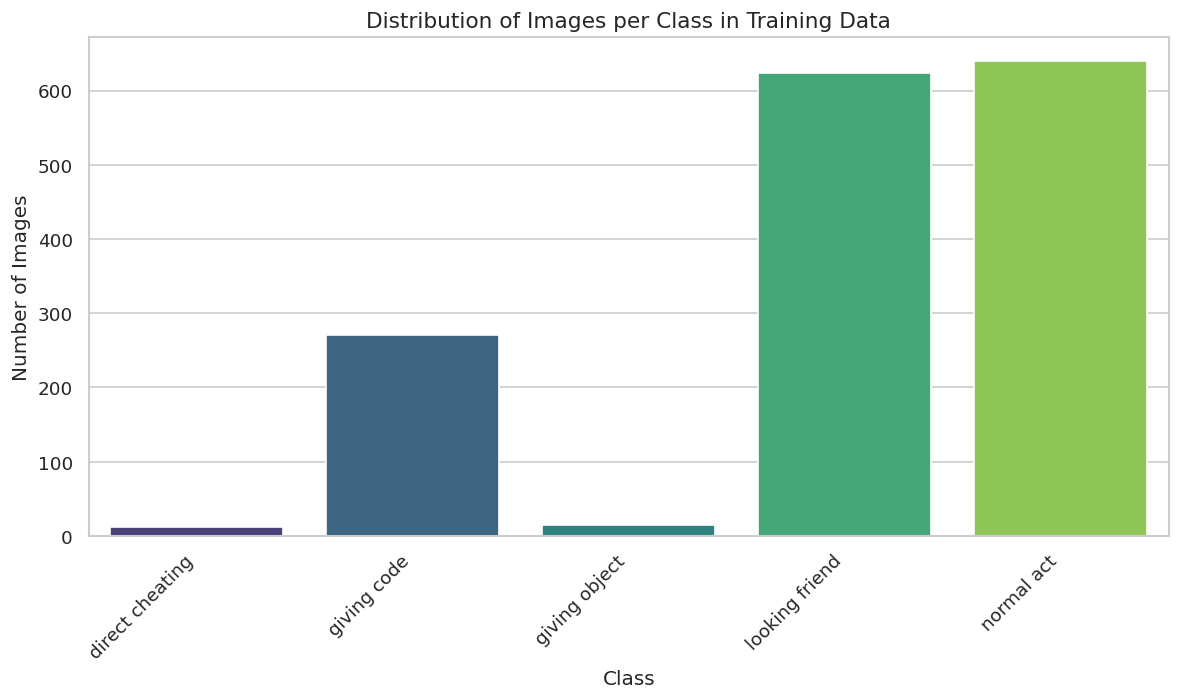

In [65]:
class_counts = Counter(full_ds.targets)
class_labels = [full_ds.classes[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(10, 6))
sns.barplot(x=class_labels, y=counts, palette='viridis')
plt.title('Distribution of Images per Class in Training Data')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 0  Mount Google Drive

In [36]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1  Install & Imports

In [37]:
import subprocess, sys
def _pip(*pkgs): subprocess.check_call([sys.executable, '-m', 'pip', 'install', *pkgs, '-q'])
for pkg, imp in [('torch','torch'),('torchvision','torchvision'),('pillow','PIL'),
                 ('scikit-learn','sklearn'),('pandas','pandas'),
                 ('matplotlib','matplotlib'),('seaborn','seaborn')]:
    try: __import__(imp)
    except ImportError: _pip(pkg)
print('All packages OK')


All packages OK


In [38]:
import os, random, time, warnings
from pathlib import Path
from collections import Counter
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


## 2  Configuration

In [39]:
DATA_ROOT  = Path('/content/drive/MyDrive/ExamCheatingDataset_preprocessed')
TRAIN_DIR  = DATA_ROOT / 'train'
TEST_DIR   = DATA_ROOT / 'test' / 'images'

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
VAL_SPLIT   = 0.20
EPOCHS_P1   = 10   # frozen backbone
EPOCHS_P2   = 10   # full fine-tune
LR_P1       = 1e-3
LR_P2       = 1e-4

CLASSES     = sorted(d.name for d in TRAIN_DIR.iterdir() if d.is_dir())
NUM_CLASSES = len(CLASSES)
NORMAL_CLS  = 'normal act'
SUB_CLASSES = [c for c in CLASSES if c != NORMAL_CLS]

print(f'Dataset : {DATA_ROOT}')
print(f'Classes : {CLASSES}')
for c in CLASSES:
    n = len(list((TRAIN_DIR / c).iterdir()))
    print(f'  {c:<20} {n:>4} images')


Dataset : /content/drive/MyDrive/ExamCheatingDataset_preprocessed
Classes : ['direct cheating', 'giving code', 'giving object', 'looking friend', 'normal act']
  direct cheating        12 images
  giving code           271 images
  giving object          15 images
  looking friend        624 images
  normal act            640 images


## 3  Data Pipeline

- Train: augmentation (flip, rotation, colour jitter, affine) to reduce overfitting on a small dataset.
- Val: resize and normalize only — no augmentation so evaluation is fair.
- Imbalance: WeightedRandomSampler oversamples rare classes during training.

In [40]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.10, 0.10)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Transforms defined.')


Transforms defined.


In [41]:
def make_loaders(train_dir, val_split=VAL_SPLIT):
    full_ds  = datasets.ImageFolder(train_dir, transform=train_tf)
    n_val    = int(len(full_ds) * val_split)
    n_train  = len(full_ds) - n_val
    train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                    generator=torch.Generator().manual_seed(SEED))
    val_ds.dataset = deepcopy(full_ds)
    val_ds.dataset.transform = val_tf

    # WeightedRandomSampler — oversample rare classes
    labels     = [full_ds.targets[i] for i in train_ds.indices]
    counts     = Counter(labels)
    weights    = [1.0 / counts[l] for l in labels]
    sampler    = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    # Class weights for loss function
    total  = sum(counts.values())
    cw     = torch.tensor([total / (NUM_CLASSES * counts[i]) for i in range(NUM_CLASSES)],
                          dtype=torch.float32).to(DEVICE)
    return train_loader, val_loader, full_ds, cw

train_loader, val_loader, full_ds, class_weights = make_loaders(TRAIN_DIR)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
print(f'Class weights: {class_weights.cpu().numpy().round(2)}')


Train batches: 40 | Val batches: 10
Class weights: [25.    1.12 22.73  0.49  0.5 ]


## 4  Shared Training Utilities

One training loop used by all models. Phase 1 freezes the backbone, Phase 2 unfreezes everything.

In [42]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1m = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1m, all_labels, all_preds


def train_two_phase(model, name, epochs_p1=EPOCHS_P1, epochs_p2=EPOCHS_P2,
                    lr1=LR_P1, lr2=LR_P2):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    history   = {'train_loss':[], 'val_acc':[], 'val_f1':[]}
    best_f1, best_state = 0.0, None

    for phase, epochs, lr in [('Phase 1 — head only', epochs_p1, lr1),
                               ('Phase 2 — full fine-tune', epochs_p2, lr2)]:
        if phase.startswith('Phase 2'):
            for p in model.parameters(): p.requires_grad_(True)
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        print(f'\n  [{name}] {phase}')
        for ep in range(1, epochs + 1):
            t0 = time.time()
            tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
            val_acc, val_f1, _, _ = evaluate(model, val_loader)
            scheduler.step()
            history['train_loss'].append(tr_loss)
            history['val_acc'].append(val_acc)
            history['val_f1'].append(val_f1)
            if val_f1 > best_f1:
                best_f1   = val_f1
                best_state = deepcopy(model.state_dict())
            print(f'    Ep {ep:02d}/{epochs} | loss {tr_loss:.3f} | '
                  f'val_acc {val_acc:.3f} | val_f1 {val_f1:.3f} | {time.time()-t0:.0f}s')

    model.load_state_dict(best_state)
    return history, best_f1


ALL_RESULTS = {}   # stores results from every model for final comparison
print('Training utilities ready.')


Training utilities ready.


---
## Model 2 — ResNet-18 (pretrained on ImageNet)

ResNet introduced skip connections (residual connections) that allow gradients to flow through very deep networks without vanishing.
ResNet-18 is the smallest variant — 18 layers, 11M parameters.

In [43]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze backbone
for p in resnet.parameters(): p.requires_grad_(False)

# Replace final classifier
in_features = resnet.fc.in_features
resnet.fc   = nn.Sequential(
    nn.Linear(in_features, 256), nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)
resnet = resnet.to(DEVICE)

total_params_rn = sum(p.numel() for p in resnet.parameters())
print(f'ResNet-18 total params: {total_params_rn:,}')


ResNet-18 total params: 11,309,125


In [44]:
resnet_history, resnet_best_f1 = train_two_phase(resnet, 'ResNet-18')



  [ResNet-18] Phase 1 — head only
    Ep 01/10 | loss 0.797 | val_acc 0.010 | val_f1 0.012 | 14s
    Ep 02/10 | loss 0.518 | val_acc 0.019 | val_f1 0.025 | 13s
    Ep 03/10 | loss 0.303 | val_acc 0.054 | val_f1 0.056 | 13s
    Ep 04/10 | loss 0.298 | val_acc 0.048 | val_f1 0.078 | 13s
    Ep 05/10 | loss 0.228 | val_acc 0.218 | val_f1 0.190 | 18s
    Ep 06/10 | loss 0.198 | val_acc 0.212 | val_f1 0.185 | 13s
    Ep 07/10 | loss 0.191 | val_acc 0.234 | val_f1 0.187 | 14s
    Ep 08/10 | loss 0.156 | val_acc 0.272 | val_f1 0.214 | 14s
    Ep 09/10 | loss 0.155 | val_acc 0.346 | val_f1 0.261 | 14s
    Ep 10/10 | loss 0.139 | val_acc 0.349 | val_f1 0.279 | 14s

  [ResNet-18] Phase 2 — full fine-tune
    Ep 01/10 | loss 0.091 | val_acc 0.388 | val_f1 0.367 | 14s
    Ep 02/10 | loss 0.067 | val_acc 0.474 | val_f1 0.391 | 14s
    Ep 03/10 | loss 0.042 | val_acc 0.580 | val_f1 0.513 | 14s
    Ep 04/10 | loss 0.037 | val_acc 0.673 | val_f1 0.550 | 14s
    Ep 05/10 | loss 0.053 | val_acc 0.670 |

In [57]:
rn_acc, rn_f1, rn_true, rn_pred = evaluate(resnet, val_loader)
ALL_RESULTS['ResNet-18'] = {'acc': rn_acc, 'f1': rn_f1, 'true': rn_true, 'pred': rn_pred,
                             'history': resnet_history, 'params': total_params_rn}
print(f'ResNet-18 — Accuracy: {rn_acc:.4f} | Macro F1: {rn_f1:.4f}')
print(classification_report(rn_true, rn_pred, target_names=CLASSES, digits=3))


ResNet-18 — Accuracy: 0.6699 | Macro F1: 0.6180
                 precision    recall  f1-score   support

direct cheating      0.333     1.000     0.500         2
    giving code      0.644     1.000     0.783        47
  giving object      0.364     1.000     0.533         4
 looking friend      0.643     0.846     0.731       117
     normal act      0.838     0.401     0.543       142

       accuracy                          0.670       312
      macro avg      0.564     0.850     0.618       312
   weighted avg      0.726     0.670     0.649       312



---
## Model 3 — MobileNet-V3-Small (pretrained on ImageNet)

MobileNet uses depthwise separable convolutions to reduce computation.
V3-Small has only 2.5M parameters — designed for mobile and edge devices where speed matters.

In [45]:
mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

# Freeze backbone
for p in mobilenet.parameters(): p.requires_grad_(False)

# Replace classifier head
in_features_mn = mobilenet.classifier[3].in_features
mobilenet.classifier[3] = nn.Linear(in_features_mn, NUM_CLASSES)
mobilenet = mobilenet.to(DEVICE)

total_params_mn = sum(p.numel() for p in mobilenet.parameters())
print(f'MobileNet-V3-Small total params: {total_params_mn:,}')


MobileNet-V3-Small total params: 1,522,981


In [46]:
mobilenet_history, mobilenet_best_f1 = train_two_phase(mobilenet, 'MobileNet-V3')



  [MobileNet-V3] Phase 1 — head only
    Ep 01/10 | loss 0.791 | val_acc 0.439 | val_f1 0.304 | 12s
    Ep 02/10 | loss 0.326 | val_acc 0.314 | val_f1 0.220 | 12s
    Ep 03/10 | loss 0.230 | val_acc 0.192 | val_f1 0.145 | 13s
    Ep 04/10 | loss 0.186 | val_acc 0.170 | val_f1 0.138 | 13s
    Ep 05/10 | loss 0.154 | val_acc 0.173 | val_f1 0.148 | 13s
    Ep 06/10 | loss 0.159 | val_acc 0.157 | val_f1 0.137 | 13s
    Ep 07/10 | loss 0.123 | val_acc 0.157 | val_f1 0.137 | 13s
    Ep 08/10 | loss 0.125 | val_acc 0.151 | val_f1 0.135 | 13s
    Ep 09/10 | loss 0.122 | val_acc 0.128 | val_f1 0.116 | 11s
    Ep 10/10 | loss 0.131 | val_acc 0.135 | val_f1 0.125 | 12s

  [MobileNet-V3] Phase 2 — full fine-tune
    Ep 01/10 | loss 0.078 | val_acc 0.369 | val_f1 0.324 | 13s
    Ep 02/10 | loss 0.049 | val_acc 0.506 | val_f1 0.351 | 13s
    Ep 03/10 | loss 0.041 | val_acc 0.580 | val_f1 0.435 | 13s
    Ep 04/10 | loss 0.043 | val_acc 0.615 | val_f1 0.418 | 13s
    Ep 05/10 | loss 0.034 | val_acc 0

In [56]:
mn_acc, mn_f1, mn_true, mn_pred = evaluate(mobilenet, val_loader)
ALL_RESULTS['MobileNet-V3'] = {'acc': mn_acc, 'f1': mn_f1, 'true': mn_true, 'pred': mn_pred,
                                'history': mobilenet_history, 'params': total_params_mn}
print(f'MobileNet-V3 — Accuracy: {mn_acc:.4f} | Macro F1: {mn_f1:.4f}')
print(classification_report(mn_true, mn_pred, target_names=CLASSES, digits=3))


MobileNet-V3 — Accuracy: 0.6987 | Macro F1: 0.5651
                 precision    recall  f1-score   support

direct cheating      0.143     1.000     0.250         2
    giving code      0.528     1.000     0.691        47
  giving object      0.400     0.500     0.444         4
 looking friend      0.760     0.786     0.773       117
     normal act      0.904     0.528     0.667       142

       accuracy                          0.699       312
      macro avg      0.547     0.763     0.565       312
   weighted avg      0.782     0.699     0.705       312



---
## Model 4 — EfficientNet-B0 (pretrained on ImageNet)

EfficientNet scales depth, width, and input resolution together using a compound coefficient.
B0 is the smallest variant — 5.3M parameters — but consistently outperforms ResNet-18 and MobileNet on accuracy.

In [47]:
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Freeze backbone
for p in efficientnet.parameters(): p.requires_grad_(False)

# Replace classifier head
in_features_en = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features_en, NUM_CLASSES)
)
efficientnet = efficientnet.to(DEVICE)

total_params_en = sum(p.numel() for p in efficientnet.parameters())
print(f'EfficientNet-B0 total params: {total_params_en:,}')


EfficientNet-B0 total params: 4,013,953


In [48]:
efficientnet_history, efficientnet_best_f1 = train_two_phase(efficientnet, 'EfficientNet-B0')



  [EfficientNet-B0] Phase 1 — head only
    Ep 01/10 | loss 0.852 | val_acc 0.029 | val_f1 0.024 | 13s
    Ep 02/10 | loss 0.526 | val_acc 0.013 | val_f1 0.012 | 13s
    Ep 03/10 | loss 0.401 | val_acc 0.022 | val_f1 0.028 | 13s
    Ep 04/10 | loss 0.361 | val_acc 0.080 | val_f1 0.089 | 13s
    Ep 05/10 | loss 0.310 | val_acc 0.170 | val_f1 0.170 | 13s
    Ep 06/10 | loss 0.279 | val_acc 0.256 | val_f1 0.233 | 12s
    Ep 07/10 | loss 0.259 | val_acc 0.218 | val_f1 0.208 | 12s
    Ep 08/10 | loss 0.252 | val_acc 0.199 | val_f1 0.193 | 13s
    Ep 09/10 | loss 0.255 | val_acc 0.240 | val_f1 0.222 | 13s
    Ep 10/10 | loss 0.254 | val_acc 0.224 | val_f1 0.211 | 13s

  [EfficientNet-B0] Phase 2 — full fine-tune
    Ep 01/10 | loss 0.120 | val_acc 0.442 | val_f1 0.357 | 15s
    Ep 02/10 | loss 0.057 | val_acc 0.590 | val_f1 0.466 | 14s
    Ep 03/10 | loss 0.041 | val_acc 0.596 | val_f1 0.521 | 14s
    Ep 04/10 | loss 0.039 | val_acc 0.631 | val_f1 0.563 | 14s
    Ep 05/10 | loss 0.034 | val

In [58]:
en_acc, en_f1, en_true, en_pred = evaluate(efficientnet, val_loader)
ALL_RESULTS['EfficientNet-B0'] = {'acc': en_acc, 'f1': en_f1, 'true': en_true, 'pred': en_pred,
                                   'history': efficientnet_history, 'params': total_params_en}
print(f'EfficientNet-B0 — Accuracy: {en_acc:.4f} | Macro F1: {en_f1:.4f}')
print(classification_report(en_true, en_pred, target_names=CLASSES, digits=3))


EfficientNet-B0 — Accuracy: 0.7340 | Macro F1: 0.6355
                 precision    recall  f1-score   support

direct cheating      0.167     1.000     0.286         2
    giving code      0.691     1.000     0.817        47
  giving object      0.444     1.000     0.615         4
 looking friend      0.723     0.803     0.761       117
     normal act      0.882     0.577     0.698       142

       accuracy                          0.734       312
      macro avg      0.581     0.876     0.635       312
   weighted avg      0.783     0.734     0.736       312



---
## Model 5 — Hierarchical Cascade (EfficientNet-B0 backbone + 2-stage SVM)

The 5-class problem has severe imbalance. The hierarchical approach splits it into two easier problems:

```
Stage 1 — Binary classifier
  cheating behaviour (922 images) vs normal act (640 images)
  ratio: 1.44x  — much easier than the raw 5-class problem
       │
       │ if predicted = cheating
       ▼
Stage 2 — Subtype classifier
  cheating (12) / giving code (271) / giving object (15) / looking friend (624)
```

The EfficientNet backbone (best single model) extracts features. SVM classifies at each stage.

In [50]:
# Use the trained EfficientNet as a feature extractor
# Strip the classifier to get 1280-dim embeddings
feat_extractor = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)  # pretrained only = clean
feat_extractor.classifier = nn.Identity()
feat_extractor = feat_extractor.to(DEVICE).eval()
for p in feat_extractor.parameters(): p.requires_grad_(False)

@torch.no_grad()
def get_embeddings(loader):
    feats, labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(DEVICE)
        emb  = feat_extractor(imgs).cpu().numpy()
        feats.append(emb)
        labels.extend(lbls.numpy())
    return np.vstack(feats), np.array(labels)

print('Extracting embeddings from trained EfficientNet backbone...')

# Use a plain loader (no sampler) for feature extraction
full_ds_plain = datasets.ImageFolder(TRAIN_DIR, transform=val_tf)
plain_loader  = DataLoader(full_ds_plain, batch_size=64, shuffle=False,
                           num_workers=NUM_WORKERS)
X_all, y_all  = get_embeddings(plain_loader)
print(f'Embeddings shape: {X_all.shape}')


Extracting embeddings from trained EfficientNet backbone...
Embeddings shape: (1562, 1280)


In [51]:
normal_idx = full_ds_plain.class_to_idx[NORMAL_CLS]

# Stage 1 — binary labels: 0=normal, 1=cheating
y_binary = (y_all != normal_idx).astype(int)
X1_tr, X1_val, y1_tr, y1_val = train_test_split(
    X_all, y_binary, test_size=VAL_SPLIT, random_state=SEED, stratify=y_binary
)

s1_model = Pipeline([('scl', StandardScaler()),
                     ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                                 class_weight='balanced', probability=True, random_state=SEED))])
s1_model.fit(X1_tr, y1_tr)
s1_preds_val = s1_model.predict(X1_val)
print(f'Stage 1 binary F1-macro: {f1_score(y1_val, s1_preds_val, average="macro"):.4f}')

# Stage 2 — 4-class subtype (cheating images only)
sub_idx_map = {full_ds_plain.class_to_idx[c]: i for i, c in enumerate(SUB_CLASSES)}
mask_cheat  = (y_all != normal_idx)
X_sub       = X_all[mask_cheat]
y_sub       = np.array([sub_idx_map[l] for l in y_all[mask_cheat]])

X2_tr, X2_val, y2_tr, y2_val = train_test_split(
    X_sub, y_sub, test_size=VAL_SPLIT, random_state=SEED, stratify=y_sub
)

s2_model = Pipeline([('scl', StandardScaler()),
                     ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                                 class_weight='balanced', probability=True, random_state=SEED))])
s2_model.fit(X2_tr, y2_tr)
print(f'Stage 2 subtype F1-macro: {f1_score(y2_val, s2_model.predict(X2_val), average="macro"):.4f}')


Stage 1 binary F1-macro: 0.9768
Stage 2 subtype F1-macro: 0.4876


In [59]:
# End-to-end evaluation on the same val split
X_val_emb, y_val_true = get_embeddings(val_loader)

s1_out      = s1_model.predict(X_val_emb)
final_preds = np.full(len(X_val_emb), normal_idx, dtype=int)

cheat_mask = (s1_out == 1)
if cheat_mask.sum() > 0:
    s2_out = s2_model.predict(X_val_emb[cheat_mask])
    orig_indices = [full_ds_plain.class_to_idx[SUB_CLASSES[i]] for i in s2_out]
    final_preds[np.where(cheat_mask)[0]] = orig_indices

# Remap to 0-based class indices
idx_to_pos = {v: k for k, v in enumerate(sorted(full_ds_plain.class_to_idx.values()))}
fp_mapped  = np.array([idx_to_pos[p] for p in final_preds])
yt_mapped  = np.array([idx_to_pos[l] for l in y_val_true])

hier_acc = accuracy_score(yt_mapped, fp_mapped)
hier_f1  = f1_score(yt_mapped, fp_mapped, average='macro', zero_division=0)
ALL_RESULTS['Hierarchical'] = {'acc': hier_acc, 'f1': hier_f1,
                                'true': yt_mapped, 'pred': fp_mapped,
                                'history': None, 'params': total_params_en}
print(f'Hierarchical — Accuracy: {hier_acc:.4f} | Macro F1: {hier_f1:.4f}')
print(classification_report(yt_mapped, fp_mapped, target_names=CLASSES, digits=3))


Hierarchical — Accuracy: 0.9904 | Macro F1: 0.9015
                 precision    recall  f1-score   support

direct cheating      1.000     0.500     0.667         2
    giving code      1.000     1.000     1.000        47
  giving object      1.000     0.750     0.857         4
 looking friend      0.975     1.000     0.987       117
     normal act      1.000     0.993     0.996       142

       accuracy                          0.990       312
      macro avg      0.995     0.849     0.902       312
   weighted avg      0.991     0.990     0.990       312



---
## Final Comparison — All 4 Models

In [60]:
rows = []
for name, r in ALL_RESULTS.items():
    rows.append({
        'Model'    : name,
        'Pretrained': 'No' if name == 'Baseline CNN' else 'Yes',
        'Params'   : f"{r['params']:,}",
        'Val Acc'  : f"{r['acc']:.4f}",
        'Macro F1' : f"{r['f1']:.4f}",
    })

df = pd.DataFrame(rows)
df = df.sort_values('Macro F1', ascending=False).reset_index(drop=True)
df.index += 1
print('=' * 65)
print('  FINAL MODEL COMPARISON')
print('=' * 65)
print(df.to_string())
print('=' * 65)
print('Primary metric: Macro F1 (equal weight per class, handles imbalance)')


  FINAL MODEL COMPARISON
             Model Pretrained      Params Val Acc Macro F1
1     Hierarchical        Yes   4,013,953  0.9904   0.9015
2  EfficientNet-B0        Yes   4,013,953  0.7340   0.6355
3        ResNet-18        Yes  11,309,125  0.6699   0.6180
4     MobileNet-V3        Yes   1,522,981  0.6987   0.5651
Primary metric: Macro F1 (equal weight per class, handles imbalance)


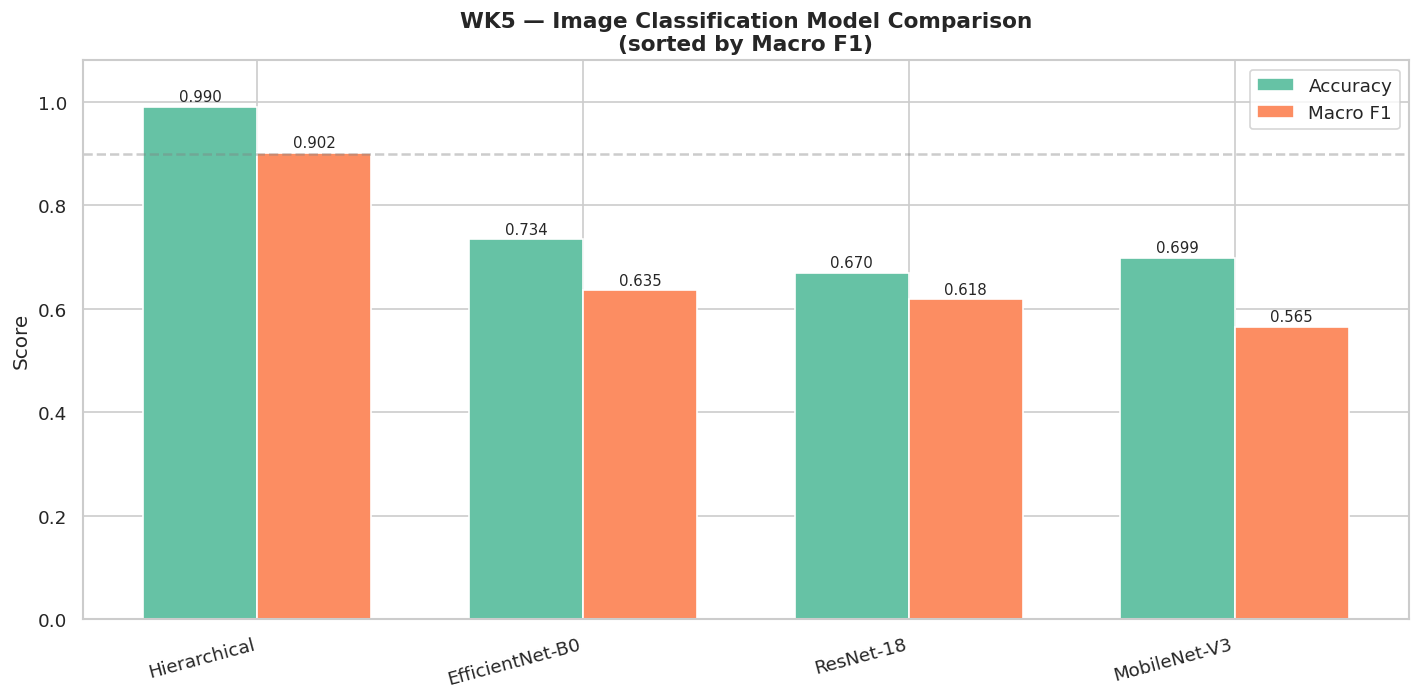

In [61]:
names  = list(ALL_RESULTS.keys())
accs   = [ALL_RESULTS[n]['acc'] for n in names]
f1s    = [ALL_RESULTS[n]['f1']  for n in names]

order  = sorted(range(len(names)), key=lambda i: f1s[i], reverse=True)
names  = [names[i]  for i in order]
accs   = [accs[i]   for i in order]
f1s    = [f1s[i]    for i in order]

x = np.arange(len(names)); w = 0.35
palette = sns.color_palette('Set2', 2)

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy', color=palette[0])
bars2 = ax.bar(x + w/2, f1s,  w, label='Macro F1',  color=palette[1])

for bar, val in zip(bars1, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('WK5 — Image Classification Model Comparison\n(sorted by Macro F1)',
             fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.9, ls='--', color='grey', alpha=0.4, label='0.9 target')
plt.tight_layout()
plt.savefig('wk5_model_comparison.png', bbox_inches='tight')
plt.show()


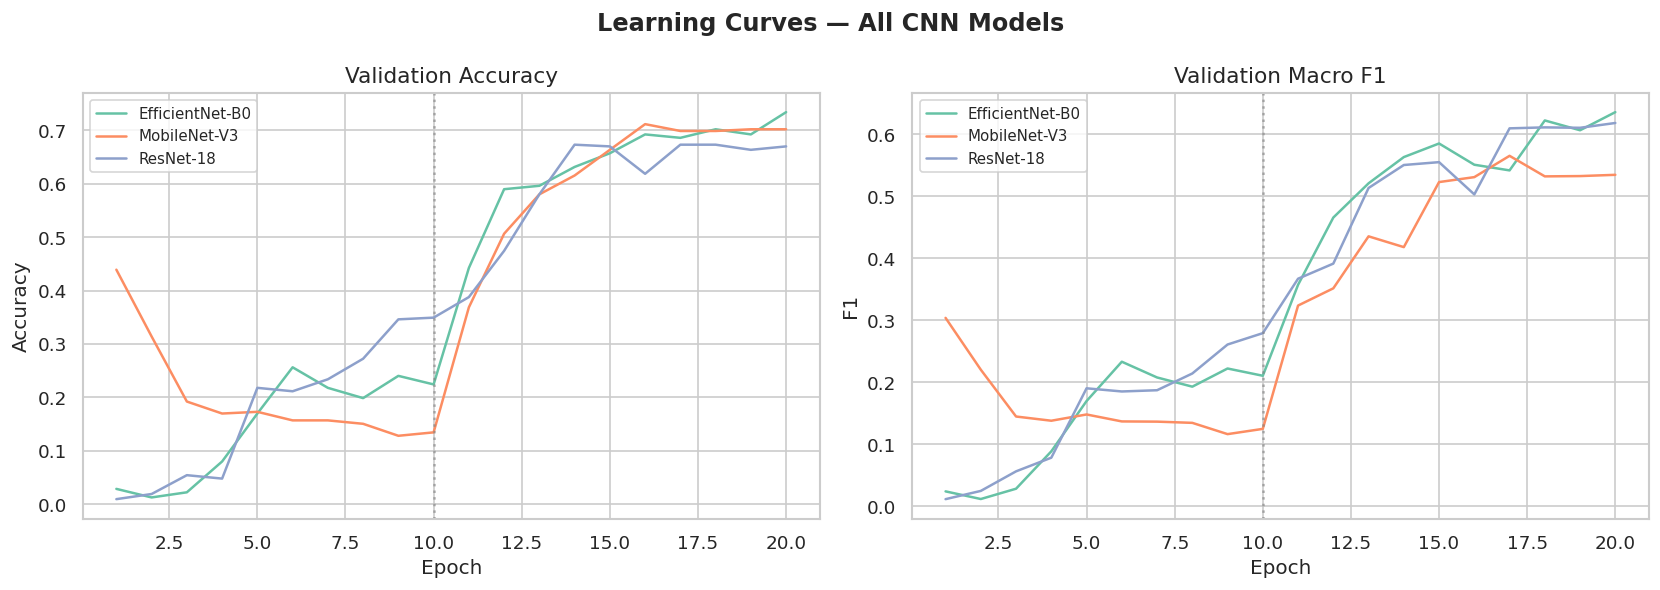

In [62]:
# Learning curves for all trained CNN models
cnn_models = {k: v for k, v in ALL_RESULTS.items() if v['history'] is not None}
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — All CNN Models', fontweight='bold')

colors = sns.color_palette('Set2', len(cnn_models))
for (name, r), color in zip(cnn_models.items(), colors):
    hist = r['history']
    ep   = range(1, len(hist['val_acc']) + 1)
    axes[0].plot(ep, hist['val_acc'],  label=name, color=color)
    axes[1].plot(ep, hist['val_f1'],   label=name, color=color)

axes[0].set_title('Validation Accuracy'); axes[0].set_ylabel('Accuracy')
axes[1].set_title('Validation Macro F1'); axes[1].set_ylabel('F1')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(fontsize=9)
    ax.axvline(EPOCHS_P1, ls=':', color='grey', alpha=0.6, label='Phase 2 starts')

plt.tight_layout()
plt.savefig('wk5_learning_curves.png', bbox_inches='tight')
plt.show()


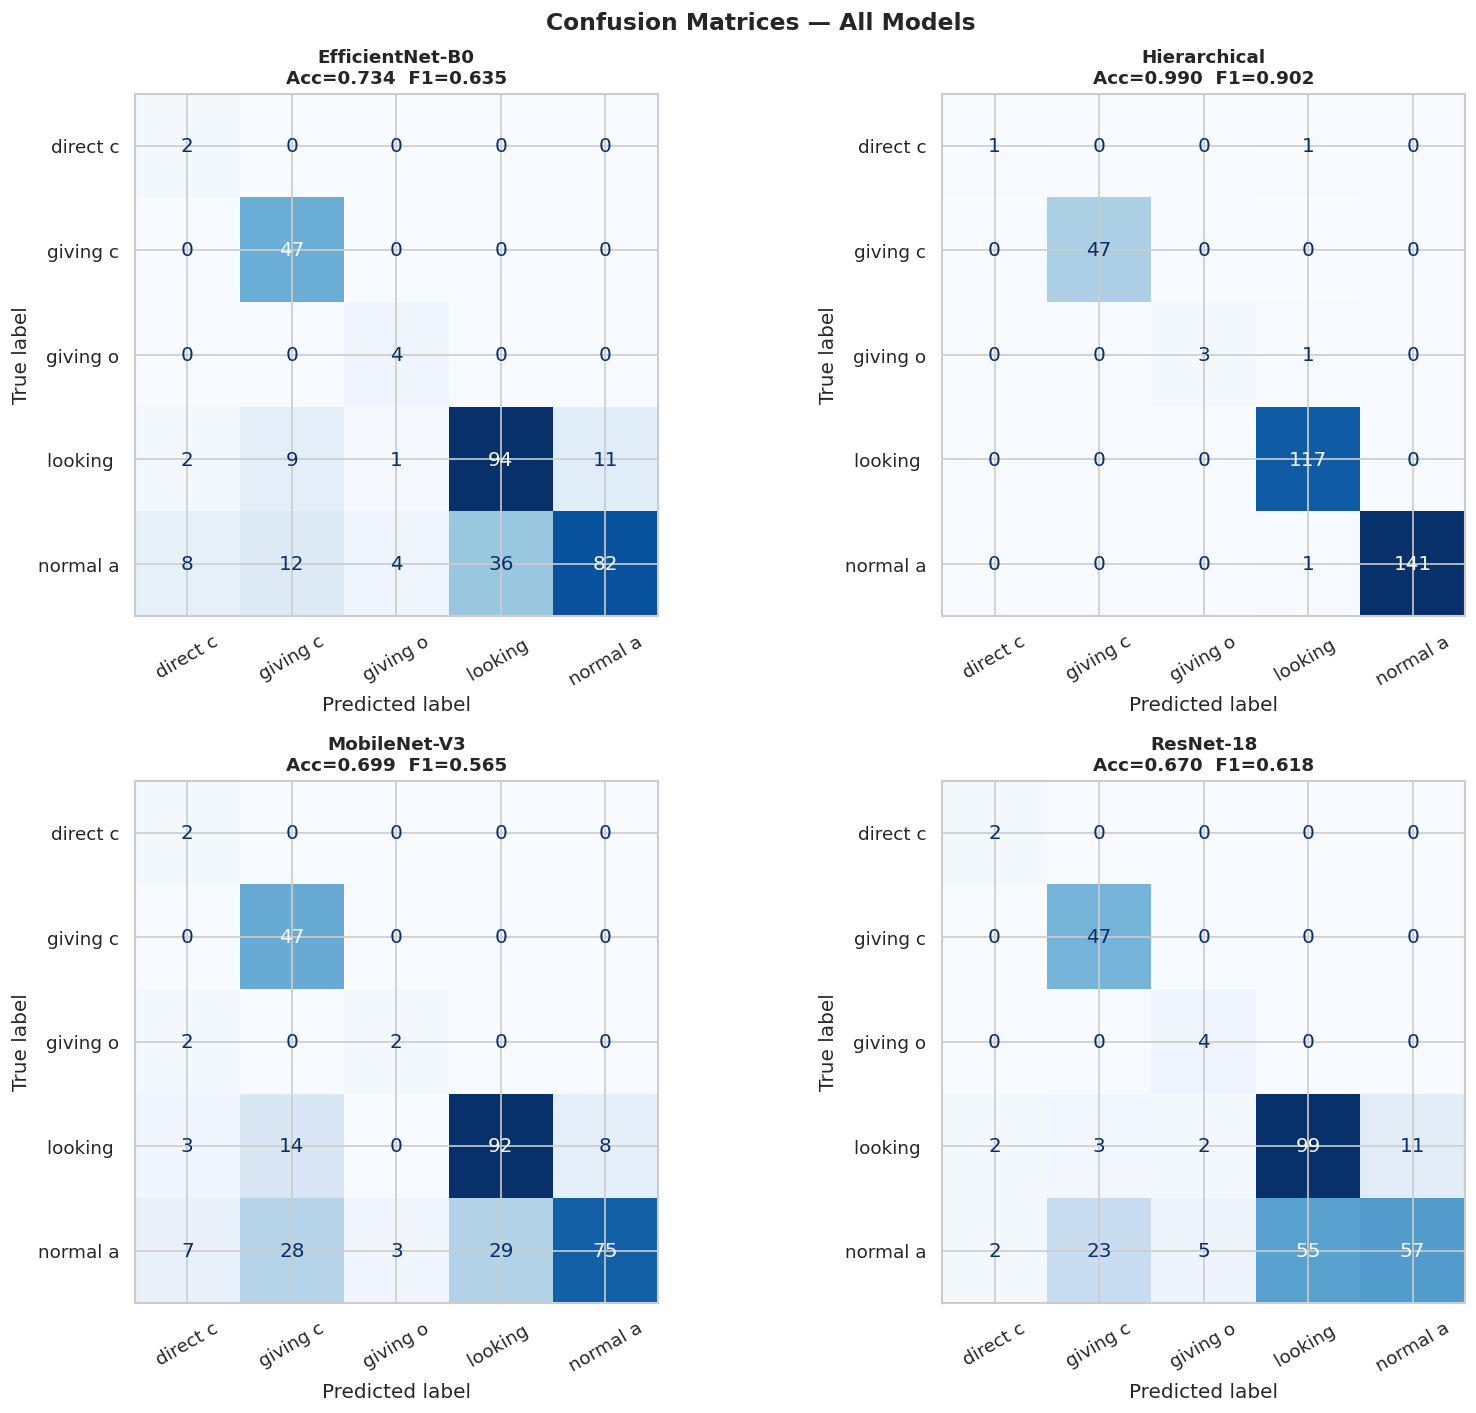

In [63]:
# Show 2 models per row
model_names = list(ALL_RESULTS.keys())
n_models = len(model_names)
ncols = 2
nrows = (n_models + 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows))
fig.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=14)
axes = axes.flatten()

for i, name in enumerate(model_names):
    r = ALL_RESULTS[name]
    cm = confusion_matrix(r['true'], r['pred'])
    ConfusionMatrixDisplay(cm, display_labels=[c[:8] for c in CLASSES]).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(f'{name}\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}',
                      fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

# Hide any empty subplot if odd number of models
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('wk5_confusion_matrices.png', bbox_inches='tight')
plt.show()


## Per-Class F1 Scores Comparison

This plot shows the F1 score for each class, comparing the performance of all models. This allows us to identify which models are stronger or weaker on specific categories, especially minority classes.

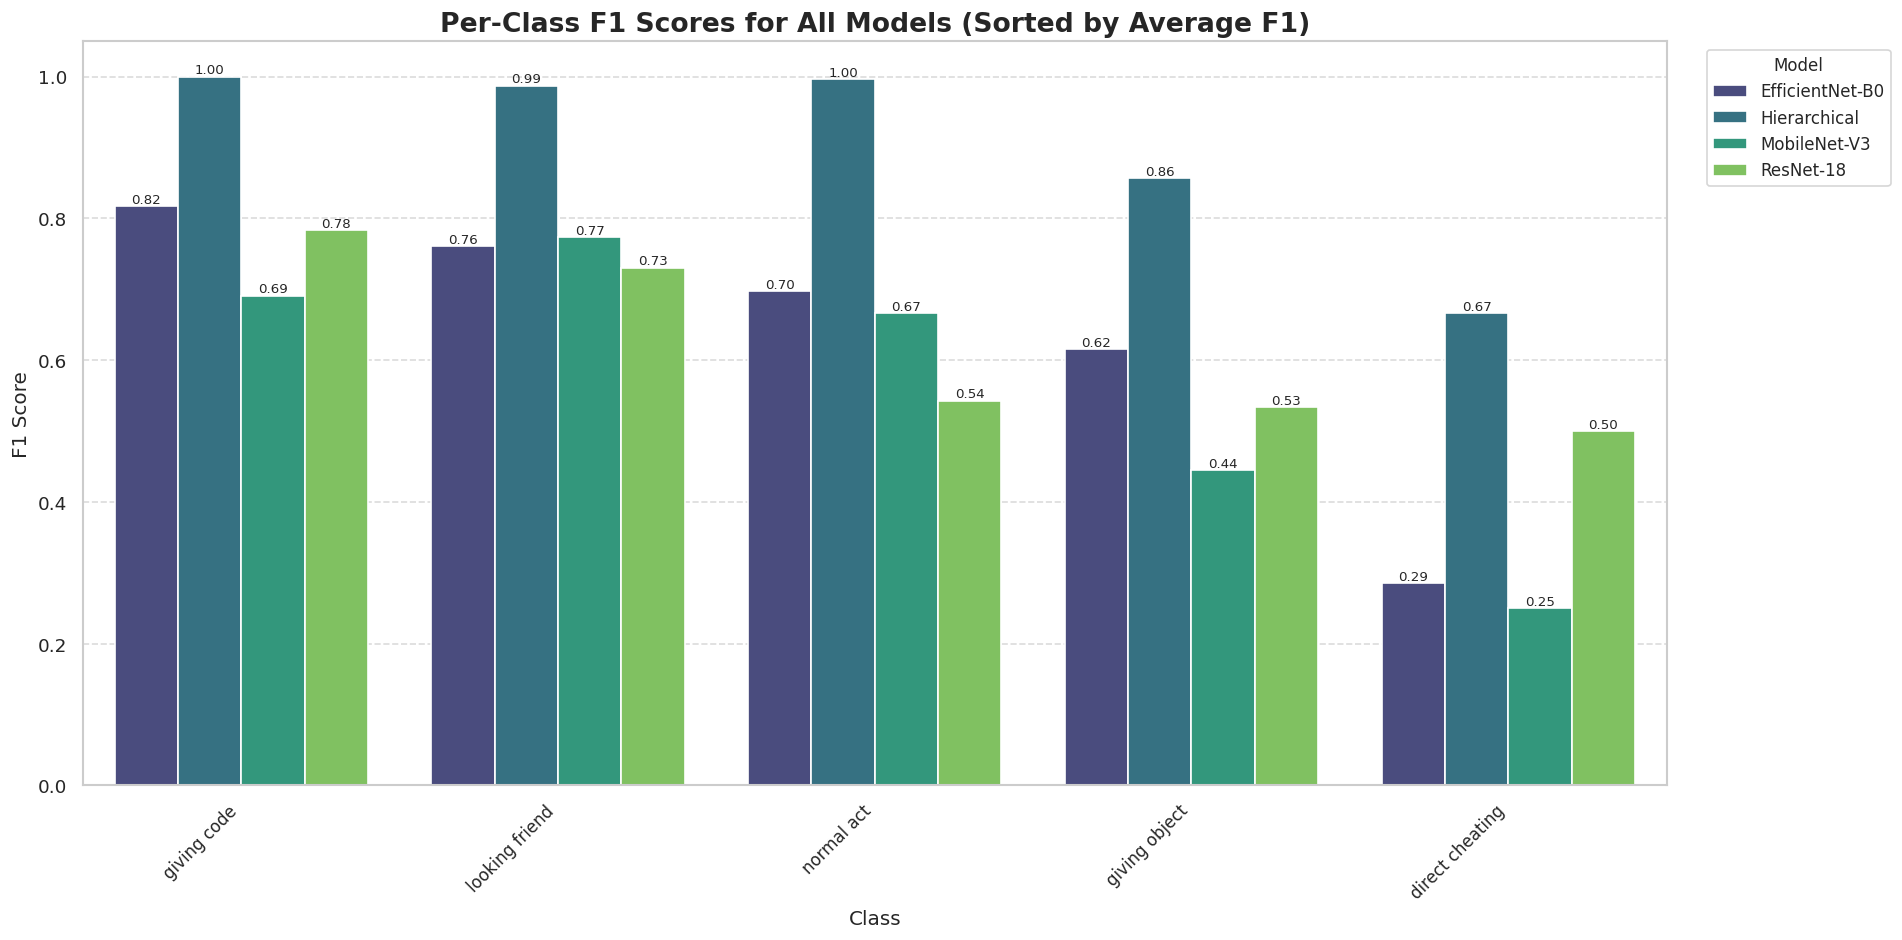

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Prepare data for plotting per-class F1 scores
per_class_f1_data = []

for model_name, results in ALL_RESULTS.items():
    report = classification_report(results['true'], results['pred'], target_names=CLASSES, output_dict=True, zero_division=0)
    for class_name in CLASSES:
        f1_score_value = report[class_name]['f1-score']
        per_class_f1_data.append({
            'Model': model_name,
            'Class': class_name,
            'F1 Score': f1_score_value
        })

df_f1 = pd.DataFrame(per_class_f1_data)

# Calculate average F1 score per class for sorting
average_f1_per_class = df_f1.groupby('Class')['F1 Score'].mean().sort_values(ascending=False).index
df_f1['Class'] = pd.Categorical(df_f1['Class'], categories=average_f1_per_class, ordered=True)

plt.figure(figsize=(16, 8))
ax = sns.barplot(data=df_f1, x='Class', y='F1 Score', hue='Model', palette='viridis', ci=None)
plt.title('Per-Class F1 Scores for All Models (Sorted by Average F1)', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, 1.05)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add F1 score values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=8)

plt.tight_layout()
plt.show()